# Telco Customer Churn - Modelovanie, tuning a finalne vyhodnotenie

Tento notebook pokryva:
- viacero modelov (`LogisticRegression`, `kNN`, `MLP`, `DecisionTree`)
- optimalizaciu hyperparametrov pomocou `RandomizedSearchCV` a `StratifiedKFold`
- finalne testovanie na testovacej mnozine
- metriky: accuracy, precision, recall, F1, average precision + PR krivka


In [1]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=ConvergenceWarning)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
MODELS_DIR = PROJECT_ROOT / "models"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

train_path = PROCESSED_DIR / "train.csv"
test_path = PROCESSED_DIR / "test.csv"
metadata_path = PROCESSED_DIR / "metadata.json"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
metadata = json.loads(metadata_path.read_text(encoding="utf-8"))

train_df.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,No,No,35,No,No phone service,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65,0
1,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55,0
2,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,Yes,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35,0
3,Female,0,Yes,No,26,Yes,No,DSL,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.70,0
4,Male,0,Yes,Yes,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.55,0


In [3]:
X_train = train_df.drop(columns=["Churn"])
y_train = train_df["Churn"].astype(int)
X_test = test_df.drop(columns=["Churn"])
y_test = test_df["Churn"].astype(int)

numeric_features = metadata["numeric_features"]
categorical_features = metadata["categorical_features"]

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (5634, 19) (5634,)
Test: (1409, 19) (1409,)


In [4]:
def make_preprocessor(scale_numeric: bool = True) -> ColumnTransformer:
    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        num_steps.append(("scaler", StandardScaler()))

    return ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=num_steps), numeric_features),
            (
                "cat",
                Pipeline(steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                ]),
                categorical_features
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


In [5]:
model_setups = {
    "logistic_regression": {
        "pipeline": Pipeline(steps=[
            ("preprocess", make_preprocessor(scale_numeric=True)),
            ("select", SelectKBest(score_func=mutual_info_classif, k=25)),
            ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
        ]),
        "params": {
            "select__k": [15, 25, 35, "all"],
            "model__C": [0.1, 0.5, 1.0, 2.0, 5.0],
            "model__class_weight": [None, "balanced"],
        },
        "n_iter": 10,
    },
    "knn": {
        "pipeline": Pipeline(steps=[
            ("preprocess", make_preprocessor(scale_numeric=True)),
            ("select", SelectKBest(score_func=mutual_info_classif, k=25)),
            ("model", KNeighborsClassifier()),
        ]),
        "params": {
            "select__k": [15, 25, 35, "all"],
            "model__n_neighbors": [5, 9, 15, 21, 31],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2],
        },
        "n_iter": 10,
    },
    "mlp": {
        "pipeline": Pipeline(steps=[
            ("preprocess", make_preprocessor(scale_numeric=True)),
            ("select", SelectKBest(score_func=mutual_info_classif, k=25)),
            ("model", MLPClassifier(
                random_state=RANDOM_STATE,
                max_iter=400,
                early_stopping=True,
                n_iter_no_change=15
            )),
        ]),
        "params": {
            "select__k": [15, 25, 35],
            "model__hidden_layer_sizes": [(32,), (64,), (64, 32)],
            "model__alpha": [1e-4, 1e-3, 1e-2],
            "model__learning_rate_init": [1e-3, 5e-3, 1e-2],
            "model__batch_size": [32, 64],
        },
        "n_iter": 10,
    },
    "decision_tree": {
        "pipeline": Pipeline(steps=[
            ("preprocess", make_preprocessor(scale_numeric=False)),
            ("select", SelectKBest(score_func=mutual_info_classif, k=25)),
            ("model", DecisionTreeClassifier(random_state=RANDOM_STATE)),
        ]),
        "params": {
            "select__k": [15, 25, 35, "all"],
            "model__max_depth": [4, 6, 8, 12, None],
            "model__min_samples_split": [2, 10, 25],
            "model__min_samples_leaf": [1, 5, 10],
            "model__class_weight": [None, "balanced"],
        },
        "n_iter": 12,
    },
}


In [6]:
best_estimators = {}
tuning_rows = []

for model_name, cfg in model_setups.items():
    print(f"\n=== Tuning: {model_name} ===")
    search = RandomizedSearchCV(
        estimator=cfg["pipeline"],
        param_distributions=cfg["params"],
        n_iter=cfg["n_iter"],
        scoring="average_precision",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=1,
        refit=True,
        verbose=1,
    )
    search.fit(X_train, y_train)

    best_estimators[model_name] = search.best_estimator_
    tuning_rows.append(
        {
            "model": model_name,
            "best_cv_average_precision": search.best_score_,
            "best_params": search.best_params_,
        }
    )

tuning_df = pd.DataFrame(tuning_rows).sort_values(
    "best_cv_average_precision", ascending=False
).reset_index(drop=True)

tuning_df



=== Tuning: logistic_regression ===
Fitting 5 folds for each of 10 candidates, totalling 50 fits



=== Tuning: knn ===
Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\Users\kuboj\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\kuboj\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")



=== Tuning: mlp ===
Fitting 5 folds for each of 10 candidates, totalling 50 fits



=== Tuning: decision_tree ===
Fitting 5 folds for each of 12 candidates, totalling 60 fits


,model,best_cv_average_precision,best_params
0,logistic_regression,0.661430,"{'select__k': 'all', 'model__class_weight': No..."
1,mlp,0.658447,"{'select__k': 35, 'model__learning_rate_init':..."
2,decision_tree,0.621596,"{'select__k': 25, 'model__min_samples_split': ..."
3,knn,0.589749,"{'select__k': 35, 'model__weights': 'distance'..."


In [7]:
cv_metric_rows = []
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "average_precision": "average_precision",
}

for model_name, estimator in best_estimators.items():
    scores = cross_validate(
        estimator,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
    )
    cv_metric_rows.append(
        {
            "model": model_name,
            "cv_accuracy_mean": np.mean(scores["test_accuracy"]),
            "cv_precision_mean": np.mean(scores["test_precision"]),
            "cv_recall_mean": np.mean(scores["test_recall"]),
            "cv_f1_mean": np.mean(scores["test_f1"]),
            "cv_average_precision_mean": np.mean(scores["test_average_precision"]),
        }
    )

cv_metrics_df = pd.DataFrame(cv_metric_rows).sort_values(
    "cv_average_precision_mean", ascending=False
).reset_index(drop=True)
cv_metrics_df


,model,cv_accuracy_mean,cv_precision_mean,cv_recall_mean,cv_f1_mean,cv_average_precision_mean
0,logistic_regression,0.802096,0.652899,0.543144,0.592316,0.661430
1,mlp,0.804405,0.658449,0.549833,0.598429,0.656510
2,decision_tree,0.792334,0.629731,0.539799,0.577883,0.621968
3,knn,0.785591,0.608039,0.545151,0.574570,0.598243


In [8]:
test_rows = []
pr_curves = {}

for model_name, estimator in best_estimators.items():
    y_pred = estimator.predict(X_test)
    y_proba = estimator.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)

    pr_curves[model_name] = {"precision": precision, "recall": recall, "ap": ap}

    test_rows.append(
        {
            "model": model_name,
            "test_accuracy": accuracy_score(y_test, y_pred),
            "test_precision": precision_score(y_test, y_pred, zero_division=0),
            "test_recall": recall_score(y_test, y_pred, zero_division=0),
            "test_f1": f1_score(y_test, y_pred, zero_division=0),
            "test_average_precision": ap,
        }
    )

test_metrics_df = pd.DataFrame(test_rows).sort_values(
    "test_average_precision", ascending=False
).reset_index(drop=True)
test_metrics_df


,model,test_accuracy,test_precision,test_recall,test_f1,test_average_precision
0,mlp,0.790632,0.617211,0.556150,0.585091,0.647907
1,logistic_regression,0.805536,0.657233,0.558824,0.604046,0.633429
2,decision_tree,0.781405,0.593220,0.561497,0.576923,0.624549
3,knn,0.774308,0.580000,0.542781,0.560773,0.588105


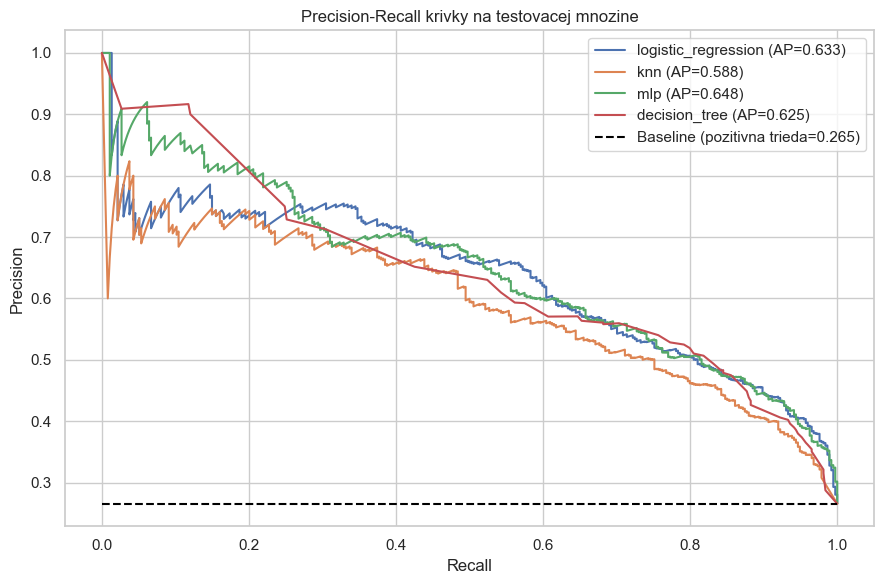

PR graf ulozeny do: C:\Users\kuboj\Desktop\INSA zadanie\reports\pr_curve_test.png


In [9]:
baseline = y_test.mean()
plt.figure(figsize=(9, 6))

for model_name, pr_data in pr_curves.items():
    plt.plot(
        pr_data["recall"],
        pr_data["precision"],
        label=f"{model_name} (AP={pr_data['ap']:.3f})",
    )

plt.hlines(
    y=baseline,
    xmin=0,
    xmax=1,
    colors="black",
    linestyles="dashed",
    label=f"Baseline (pozitivna trieda={baseline:.3f})",
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall krivky na testovacej mnozine")
plt.legend()
plt.tight_layout()

pr_plot_path = REPORTS_DIR / "pr_curve_test.png"
plt.savefig(pr_plot_path, dpi=200)
plt.show()

print("PR graf ulozeny do:", pr_plot_path)


In [10]:
best_model_name = test_metrics_df.iloc[0]["model"]
best_model = best_estimators[best_model_name]

print("Najlepsi model podla test AP:", best_model_name)
print()
print(classification_report(y_test, best_model.predict(X_test), digits=4))


Najlepsi model podla test AP: mlp

              precision    recall  f1-score   support

           0     0.8451    0.8754    0.8600      1035
           1     0.6172    0.5561    0.5851       374

    accuracy                         0.7906      1409
   macro avg     0.7312    0.7158    0.7225      1409
weighted avg     0.7846    0.7906    0.7870      1409



In [11]:
tuning_path = REPORTS_DIR / "tuning_summary.csv"
cv_metrics_path = REPORTS_DIR / "cv_metrics.csv"
test_metrics_path = REPORTS_DIR / "test_metrics.csv"
best_model_path = MODELS_DIR / "best_model.joblib"

tuning_df.to_csv(tuning_path, index=False)
cv_metrics_df.to_csv(cv_metrics_path, index=False)
test_metrics_df.to_csv(test_metrics_path, index=False)
joblib.dump(best_model, best_model_path)

print("Ulozene subory:")
print("-", tuning_path)
print("-", cv_metrics_path)
print("-", test_metrics_path)
print("-", best_model_path)


Ulozene subory:
- C:\Users\kuboj\Desktop\INSA zadanie\reports\tuning_summary.csv
- C:\Users\kuboj\Desktop\INSA zadanie\reports\cv_metrics.csv
- C:\Users\kuboj\Desktop\INSA zadanie\reports\test_metrics.csv
- C:\Users\kuboj\Desktop\INSA zadanie\models\best_model.joblib
